In [1]:
import numpy as np
import pyoti.sparse as oti
import itertools
from jetgp.full_gddegp.gddegp import gddegp
from scipy.stats import qmc
import jetgp.utils as utils

n_order = 1
n_bases = 3
num_directions_per_point = 3  # gradient + 2 perpendicular directions
num_training_pts = 50
domain_bounds = ((0.0, 1.0), (0.0, 1.0), (0.0, 1.0))
normalize_data = True
kernel = "SE"
kernel_type = "anisotropic"
n_restarts = 15
swarm_size = 200
random_seed = 42
np.random.seed(random_seed)

print("GDDEGP 3D Example: Hartmann3 Function")
print(f"Training points: {num_training_pts}")
print(f"Directions per point: {num_directions_per_point}")
print(f"Total observations: {num_training_pts * (1 + num_directions_per_point)}")

/home/sam/anaconda3/envs/pyoti_2/lib/python3.9/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)


GDDEGP 3D Example: Hartmann3 Function
Training points: 50
Directions per point: 3
Total observations: 200


In [2]:
def hartmann3(X, alg=np):
    """3D Hartmann function - standard optimization benchmark."""
    alpha = np.array([1.0, 1.2, 3.0, 3.2])
    A = np.array([[3.0, 10, 30],
                  [0.1, 10, 35],
                  [3.0, 10, 30],
                  [0.1, 10, 35]])
    P = 1e-4 * np.array([[3689, 1170, 2673],
                         [4699, 4387, 7470],
                         [1091, 8732, 5547],
                         [381, 5743, 8828]])

    result = alg.zeros(X.shape[0]) if hasattr(alg, 'zeros') else np.zeros(X.shape[0])
    for i in range(4):
        inner = alg.zeros(X.shape[0]) if hasattr(alg, 'zeros') else np.zeros(X.shape[0])
        for j in range(3):
            inner = inner + A[i, j] * (X[:, j] - P[i, j])**2
        result = result - alpha[i] * alg.exp(-inner)
    return result

def hartmann3_gradient(x1, x2, x3):
    """Analytical gradient of Hartmann3 function."""
    alpha = np.array([1.0, 1.2, 3.0, 3.2])
    A = np.array([[3.0, 10, 30],
                  [0.1, 10, 35],
                  [3.0, 10, 30],
                  [0.1, 10, 35]])
    P = 1e-4 * np.array([[3689, 1170, 2673],
                         [4699, 4387, 7470],
                         [1091, 8732, 5547],
                         [381, 5743, 8828]])

    grad = np.zeros(3)
    X = np.array([x1, x2, x3])

    for i in range(4):
        inner = np.sum(A[i, :] * (X - P[i, :])**2)
        exp_term = np.exp(-inner)
        for j in range(3):
            grad[j] += 2 * alpha[i] * A[i, j] * (X[j] - P[i, j]) * exp_term

    return grad

In [3]:
def gram_schmidt_orthonormal(v1):
    """
    Generate 2 orthonormal vectors perpendicular to v1.
    v1 should be a unit vector.
    """
    # Find a vector not parallel to v1
    if abs(v1[0]) < 0.9:
        v2_init = np.array([1.0, 0.0, 0.0])
    else:
        v2_init = np.array([0.0, 1.0, 0.0])

    # First perpendicular vector
    v2 = v2_init - np.dot(v2_init, v1) * v1
    v2 = v2 / np.linalg.norm(v2)

    # Second perpendicular vector
    v3 = np.cross(v1, v2)
    v3 = v3 / np.linalg.norm(v3)

    return v2, v3

In [4]:
def generate_training_data():
    """Generate GDDEGP training data with multiple rays per point."""
    # Latin Hypercube Sampling
    sampler = qmc.LatinHypercube(d=n_bases, seed=random_seed)
    unit_samples = sampler.random(n=num_training_pts)
    X_train = qmc.scale(unit_samples,
                        [b[0] for b in domain_bounds],
                        [b[1] for b in domain_bounds])

    print("Generating directional derivatives...")

    # Create rays: gradient + 2 perpendicular directions
    rays_list = [[] for _ in range(num_directions_per_point)]
    for idx, (x1, x2, x3) in enumerate(X_train):
        # Compute gradient direction
        grad = hartmann3_gradient(x1, x2, x3)
        grad_norm = np.linalg.norm(grad)

        if grad_norm > 1e-10:
            ray_grad = grad / grad_norm
        else:
            ray_grad = np.array([1.0, 0.0, 0.0])

        # Generate perpendicular directions
        ray_perp1, ray_perp2 = gram_schmidt_orthonormal(ray_grad)

        rays_list[0].append(ray_grad.reshape(-1, 1))
        rays_list[1].append(ray_perp1.reshape(-1, 1))
        rays_list[2].append(ray_perp2.reshape(-1, 1))

        if idx < 3:  # Show first few
            print(f"  Point {idx}: grad={ray_grad}")

    # Apply global perturbations
    X_pert = oti.array(X_train)
    for i in range(num_directions_per_point):
        e_tag = oti.e(i+1, order=n_order)
        for j in range(len(rays_list[i])):
            perturbation = oti.array(rays_list[i][j]) * e_tag
            X_pert[j, :] += perturbation.T

    # Evaluate with hypercomplex AD
    f_hc = hartmann3(X_pert, alg=oti)

    # Truncate cross-derivatives
    for combo in itertools.combinations(range(1, num_directions_per_point+1), 2):
        f_hc = f_hc.truncate(combo)

    # Extract derivatives
    y_train_list = [f_hc.real.reshape(-1, 1)]
    der_indices_to_extract = [ [ [[i, 1]] for i in range(1, num_directions_per_point+1)]]

    for group in der_indices_to_extract:
        for sub_group in group:
            y_train_list.append(f_hc.get_deriv(sub_group).reshape(-1, 1))

    print(f"Data structure:")
    print(f"  Function values: {y_train_list[0].shape}")
    for i in range(1, len(y_train_list)):
        print(f"  Direction {i} derivatives: {y_train_list[i].shape}")

    return {'X_train': X_train,
            'y_train_list': y_train_list,
            'rays_list': rays_list,
            'der_indices': der_indices_to_extract}

training_data = generate_training_data()

Generating directional derivatives...
  Point 0: grad=[ 0.13366276 -0.03709979 -0.9903322 ]
  Point 1: grad=[0.28965432 0.082479   0.95357097]
  Point 2: grad=[0.01400605 0.23698152 0.97141319]
Data structure:
  Function values: (50, 1)
  Direction 1 derivatives: (50, 1)
  Direction 2 derivatives: (50, 1)
  Direction 3 derivatives: (50, 1)


In [5]:
def train_model(training_data):
    """Initialize and train GDDEGP model."""
    print("Training GDDEGP model...")

    rays_array = [np.hstack(training_data['rays_list'][i])
                  for i in range(num_directions_per_point)]
    derivative_locations = []
    for i in range(len(training_data['der_indices'])):
        for j in range(len(training_data['der_indices'][i])):
            derivative_locations.append([i for i in range(len(training_data['X_train']))])
    gp_model = gddegp(
        training_data['X_train'],
        training_data['y_train_list'],
        n_order=1,
        rays_list=rays_array,
        der_indices=training_data['der_indices'],
        derivative_locations = derivative_locations,
        normalize=normalize_data,
        kernel=kernel,
        kernel_type=kernel_type
    )

    print("Optimizing hyperparameters...")
    params = gp_model.optimize_hyperparameters(
    optimizer='jade',
    pop_size = 100,
    n_generations = 15,
    local_opt_every = 5,
    debug = True
    )
    return gp_model, params

gp_model, params = train_model(training_data)

Training GDDEGP model...
Optimizing hyperparameters...


Gen 1: best f=491.77059448837406


Gen 2: best f=491.77059448837406
Gen 3: best f=491.77059448837406


Gen 4: best f=491.77059448837406


Local refinement improved at gen 5: f=62.41236399337933
Gen 5: best f=62.41236399337933
Gen 6: best f=62.41236399337933


Gen 7: best f=62.41236399337933
Gen 8: best f=62.41236399337933


Gen 9: best f=62.41236399337933


Local refinement improved at gen 10: f=-31.292717633131133
Gen 10: best f=-31.292717633131133
Stopping: Objective improvement < 1e-06 at generation 10


In [6]:
def evaluate_model(gp_model, params, training_data):
    """Evaluate GDDEGP on test points."""
    print("Evaluating model on test set...")

    # Generate test points
    n_test = 1000
    sampler = qmc.LatinHypercube(d=n_bases, seed=random_seed + 1)
    unit_test = sampler.random(n=n_test)
    X_test = qmc.scale(unit_test,
                       [b[0] for b in domain_bounds],
                       [b[1] for b in domain_bounds])


    # Predict
    y_pred_full = gp_model.predict(
        X_test, params,
        calc_cov=False, return_deriv=False
    )
    y_pred = y_pred_full[:n_test]

    # Ground truth
    y_true = hartmann3(X_test, alg=np)

    # Error metrics
    nrmse = utils.nrmse(y_true.flatten(), y_pred.flatten())
    mae = np.mean(np.abs(y_true - y_pred))
    max_error = np.max(np.abs(y_true - y_pred))

    print(f"Test set size: {n_test} points")
    print(f"Performance metrics:")
    print(f"  NRMSE: {nrmse:.6f}")
    print(f"  MAE:   {mae:.6f}")
    print(f"  Max error: {max_error:.6f}")

    return nrmse, mae, max_error

nrmse, mae, max_error = evaluate_model(gp_model, params, training_data)

Evaluating model on test set...
Test set size: 1000 points
Performance metrics:
  NRMSE: 0.003981
  MAE:   0.007087
  Max error: 0.127406


Generating visualizations...


  Slice $x_3=0.5$: 5 training points nearby


  Slice $x_2=0.5$: 4 training points nearby


  Slice $x_1=0.5$: 6 training points nearby


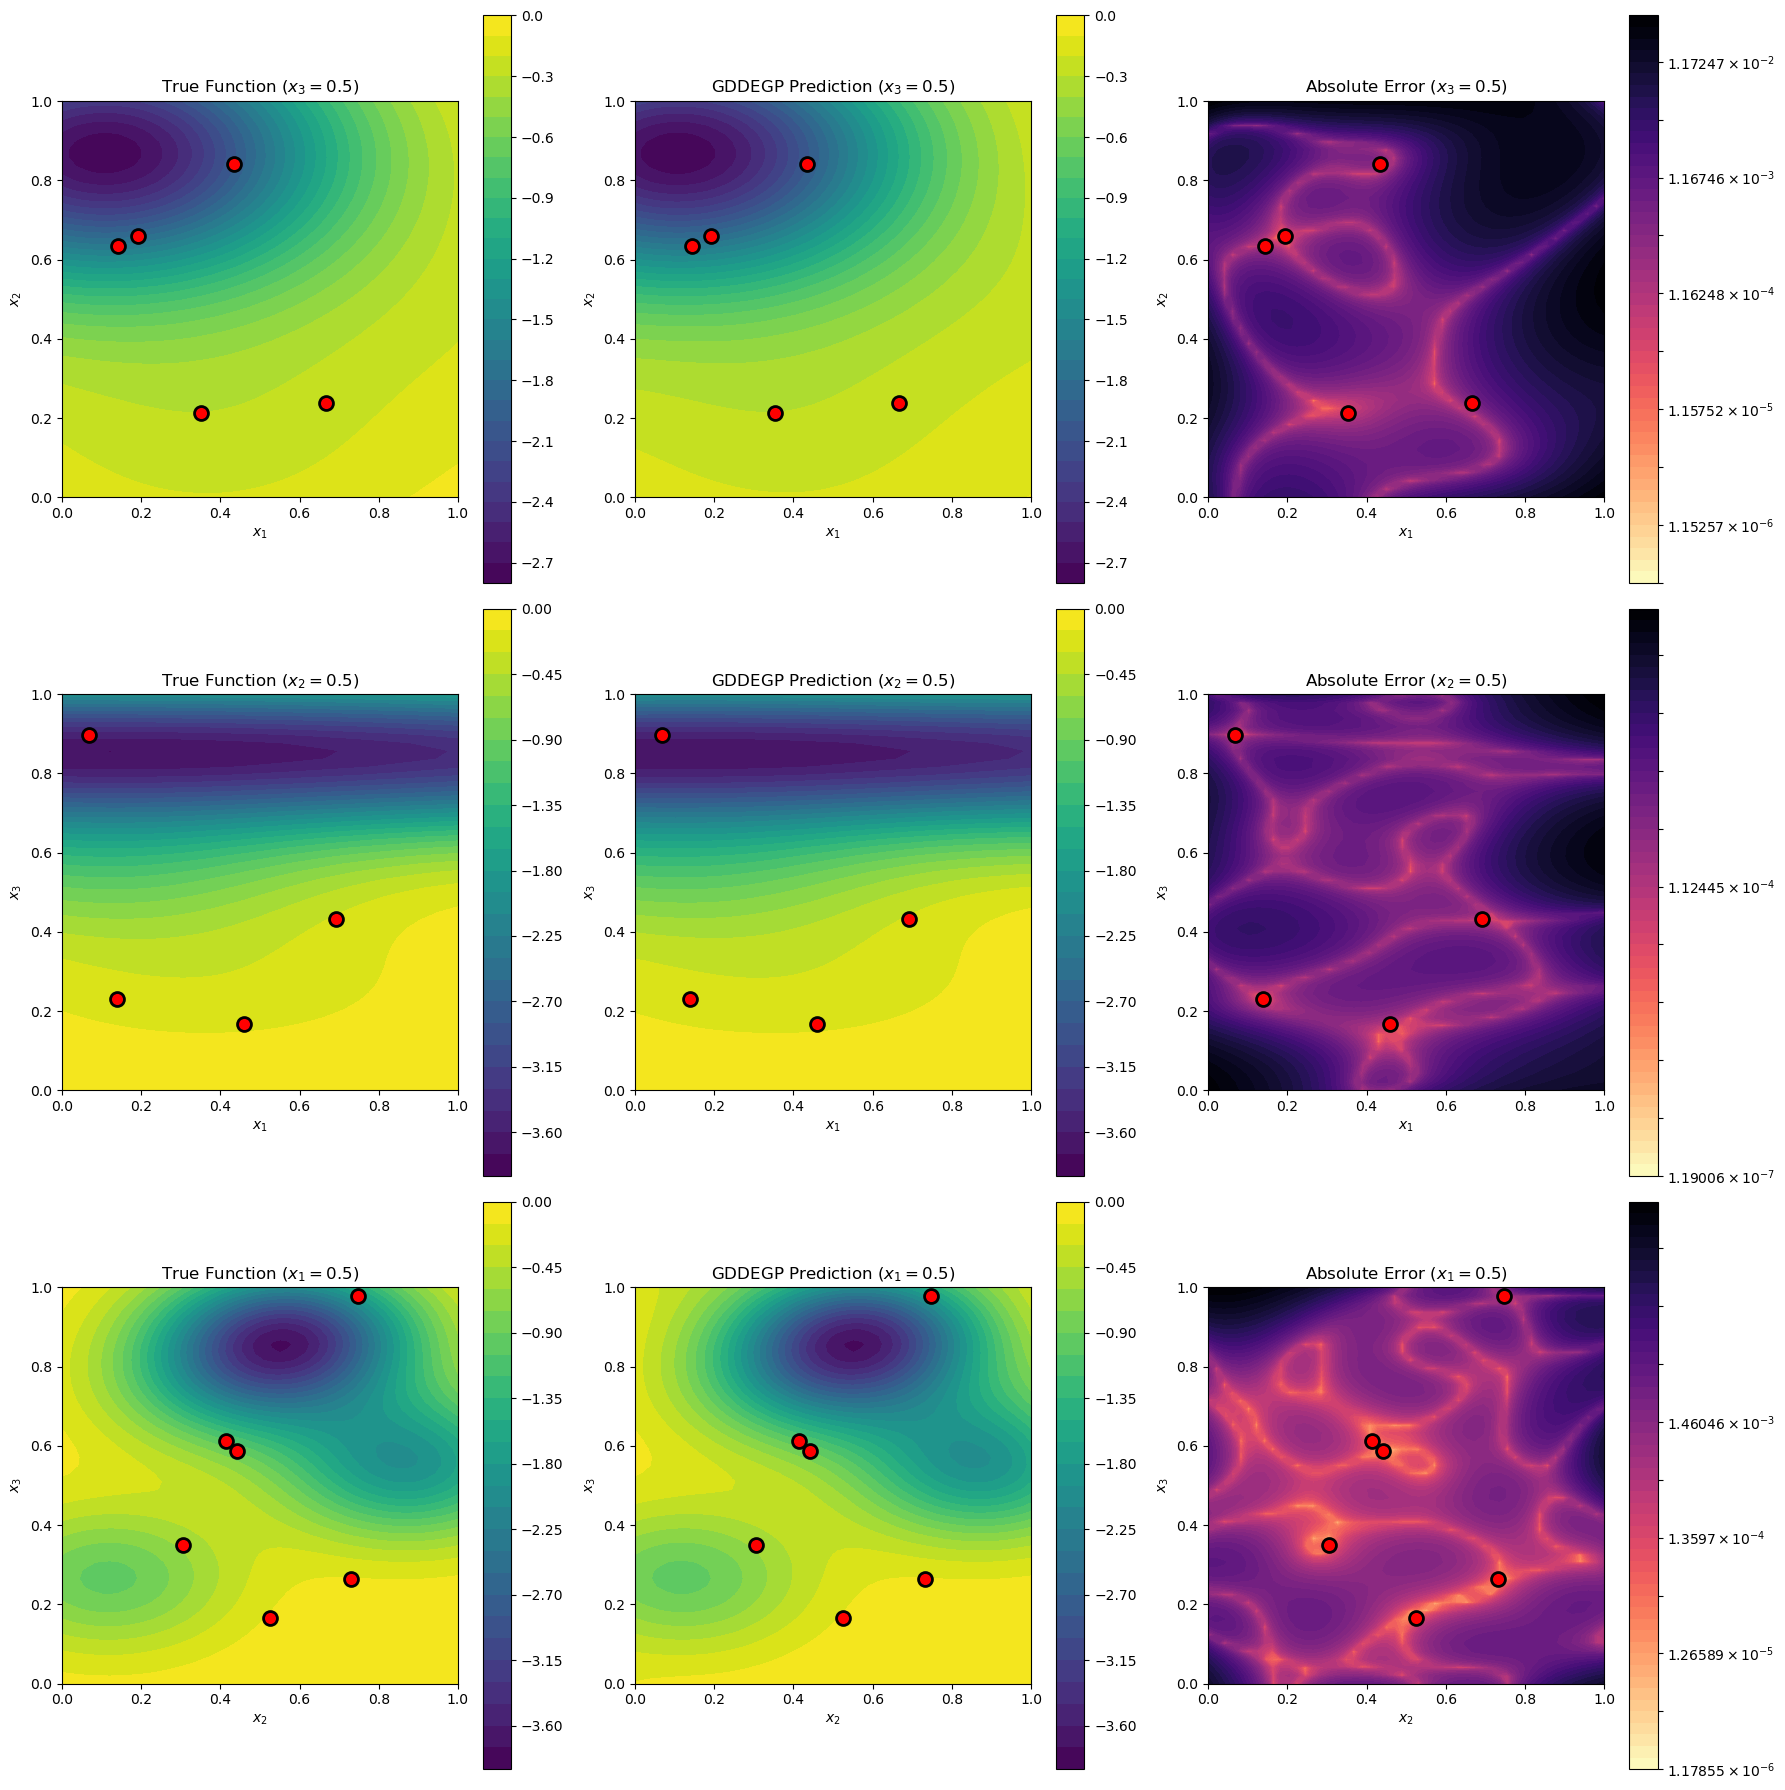

In [7]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def visualize_slices(gp_model, params, training_data):
    """Visualize 2D slices through the 3D function."""
    print("Generating visualizations...")

    X_train = training_data['X_train']
    n_points = 50

    # Define three slice configurations
    slices = [
        {'name': '$x_3=0.5$', 'fixed_dim': 2, 'fixed_val': 0.5,
         'var_dims': [0, 1], 'labels': ['$x_1$', '$x_2$']},
        {'name': '$x_2=0.5$', 'fixed_dim': 1, 'fixed_val': 0.5,
         'var_dims': [0, 2], 'labels': ['$x_1$', '$x_3$']},
        {'name': '$x_1=0.5$', 'fixed_dim': 0, 'fixed_val': 0.5,
         'var_dims': [1, 2], 'labels': ['$x_2$', '$x_3$']}
    ]

    fig, axes = plt.subplots(3, 3, figsize=(18, 18))

    for row, slice_info in enumerate(slices):
        fixed_dim = slice_info['fixed_dim']
        fixed_val = slice_info['fixed_val']
        var_dims = slice_info['var_dims']

        # Create slice grid
        x1_vals = np.linspace(0, 1, n_points)
        x2_vals = np.linspace(0, 1, n_points)
        X1_grid, X2_grid = np.meshgrid(x1_vals, x2_vals)

        # Build full 3D points for this slice
        X_slice = np.zeros((n_points * n_points, 3))
        X_slice[:, var_dims[0]] = X1_grid.ravel()
        X_slice[:, var_dims[1]] = X2_grid.ravel()
        X_slice[:, fixed_dim] = fixed_val

        # Predict
        dummy_ray = np.array([[1.0], [0.0], [0.0]])
        rays_pred = [np.hstack([dummy_ray for _ in range(len(X_slice))])
                     for _ in range(num_directions_per_point)]

        y_pred_full = gp_model.predict(X_slice, params,
                                        calc_cov=False, return_deriv=False)
        y_pred = y_pred_full[:len(X_slice)].reshape(n_points, n_points)

        # Ground truth
        y_true = hartmann3(X_slice, alg=np).reshape(n_points, n_points)

        # Error
        abs_error = np.abs(y_pred - y_true)
        abs_error_clipped = np.clip(abs_error, 1e-8, None)

        # Filter training points in this slice
        tol = 0.05
        in_slice = np.abs(X_train[:, fixed_dim] - fixed_val) < tol
        X_train_slice = X_train[in_slice]

        # Plot 1: True function
        ax = axes[row, 0]
        c = ax.contourf(X1_grid, X2_grid, y_true, levels=30, cmap='viridis')
        if len(X_train_slice) > 0:
            ax.scatter(X_train_slice[:, var_dims[0]], X_train_slice[:, var_dims[1]],
                      c='red', s=100, edgecolors='k', linewidths=2, zorder=5, marker='o')
        ax.set_xlabel(slice_info['labels'][0])
        ax.set_ylabel(slice_info['labels'][1])
        ax.set_title(f"True Function ({slice_info['name']})")
        ax.set_aspect('equal')
        plt.colorbar(c, ax=ax)

        # Plot 2: Prediction
        ax = axes[row, 1]
        c = ax.contourf(X1_grid, X2_grid, y_pred, levels=30, cmap='viridis')
        if len(X_train_slice) > 0:
            ax.scatter(X_train_slice[:, var_dims[0]], X_train_slice[:, var_dims[1]],
                      c='red', s=100, edgecolors='k', linewidths=2, zorder=5, marker='o')
        ax.set_xlabel(slice_info['labels'][0])
        ax.set_ylabel(slice_info['labels'][1])
        ax.set_title(f"GDDEGP Prediction ({slice_info['name']})")
        ax.set_aspect('equal')
        plt.colorbar(c, ax=ax)

        # Plot 3: Error
        ax = axes[row, 2]
        log_levels = np.logspace(np.log10(abs_error_clipped.min()),
                                np.log10(abs_error_clipped.max()), num=50)
        c = ax.contourf(X1_grid, X2_grid, abs_error_clipped,
                       levels=log_levels, norm=LogNorm(), cmap='magma_r')
        if len(X_train_slice) > 0:
            ax.scatter(X_train_slice[:, var_dims[0]], X_train_slice[:, var_dims[1]],
                      c='red', s=100, edgecolors='k', linewidths=2, zorder=5, marker='o')
        ax.set_xlabel(slice_info['labels'][0])
        ax.set_ylabel(slice_info['labels'][1])
        ax.set_title(f"Absolute Error ({slice_info['name']})")
        ax.set_aspect('equal')
        plt.colorbar(c, ax=ax)

        print(f"  Slice {slice_info['name']}: {len(X_train_slice)} training points nearby")

    plt.tight_layout()
    plt.show()

visualize_slices(gp_model, params, training_data)

In [8]:
print("GDDEGP 3D Example Summary")
print("="*70)
print(f"Function: Hartmann3 (3D)")
print(f"Training points: {num_training_pts}")
print(f"Directions per point: {num_directions_per_point} (gradient + 2 perpendicular)")
print(f"Total derivative observations: {num_training_pts * num_directions_per_point}")
print(f"Final NRMSE: {nrmse:.6f}")
print(f"\nKey features demonstrated:")
print("  - 3D function approximation")
print("  - Multiple orthogonal directions per point")
print("  - Gradient-aligned primary direction")
print("  - Gram-Schmidt orthogonalization for perpendicular rays")
print("  - Hypercomplex automatic differentiation")
print("  - 2D slice visualizations through 3D space")

GDDEGP 3D Example Summary
Function: Hartmann3 (3D)
Training points: 50
Directions per point: 3 (gradient + 2 perpendicular)
Total derivative observations: 150
Final NRMSE: 0.003981

Key features demonstrated:
  - 3D function approximation
  - Multiple orthogonal directions per point
  - Gradient-aligned primary direction
  - Gram-Schmidt orthogonalization for perpendicular rays
  - Hypercomplex automatic differentiation
  - 2D slice visualizations through 3D space
